In [1]:
try:
    import smolgp
except ImportError:
    %pip install -q smolgp

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
key = jax.random.PRNGKey(0)

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('font', family='sans serif', size=16)

(multivariate)=

# Multivariate Data

A multivariate GP has a vector-valued output **f**(t), where **f** is now a vector of multiple dependent simultaneous output functions that share a common time correlated behavior (though perhaps with varying amplitudes). An example is a series of $D$ parallel timeseries where each timeseries is taken at identical timestamps: $\boldsymbol{f}(t) = (f_1(t), \dots, f_D(t))$.

There are two ways to handle such data in `smolgp`. One is to flatten the $D$ timeseries into a single 1-D datastream and label each measurement with an index which is used to "select" the appropriate amplitude hyperparameter in the kernel's `observation_model`, as is done in the [`tinygp` tutorial here](https://tinygp.readthedocs.io/en/latest/tutorials/quasisep-custom.html#multivariate-quasiseparable-kernels). Another is to simply input multidimensional `noise` (N, D, D) and `y` (N, D) arrays when defining and conditioning the GP object. Each of the $N$ measurements will have a $1 \times D$ vector of measurements and a $D \times D$ covariance matrix.

Let's build an example model for a pair of observed time series, 
\begin{align}
\boldsymbol{y}_k = \begin{pmatrix} y_{1,k} \\
            y_{2,k} \\
       \end{pmatrix}.
\end{align}
which will share a common underlying kernel (let's pick the Matérn-5/2 kernel), but for fun let's have $y_1$ measure the value of the latent state (times an amplitude $A$) and $y_2$ will measure its derivative (times another amplitude $B$). We can define this with the following observation matrix
\begin{align}
\boldsymbol{H}_k = \begin{pmatrix} A & 0 & 0 \\
            0 & B & 0\\
       \end{pmatrix}
\end{align}

which gives us the joint observation model for the output vector
\begin{align}
\boldsymbol{y}_k = \boldsymbol{H}_k \boldsymbol{x}_k + \boldsymbol{\epsilon}_k = 
       \begin{pmatrix} A & 0 & 0\\ 0 & B & 0 \\ \end{pmatrix} \begin{pmatrix} x_k \\ \dot{x}_k \\ \ddot{x}_k \end{pmatrix} + \begin{pmatrix} \epsilon_{y_1,k} \\ \epsilon_{y_2,k} \end{pmatrix}
       = \begin{pmatrix} A x_k + \epsilon_{y_1,k} \\ B \dot{x}_k + \epsilon_{y_2,k} \end{pmatrix}
\end{align}

where the measurement noise is drawn from $\boldsymbol{\epsilon}_k \sim \mathcal{N}(0,\boldsymbol{R}_k)$ where
\begin{align}
\boldsymbol{R}_k = 
       \begin{pmatrix} \sigma_{y_1}^2 & \sigma_{y_1 y_2}^2 \\
          \sigma_{y_2 y_1}^2 & \sigma_{y_2}^2
          \end{pmatrix}.
\end{align}
If our two measurements $y_1$ and $y_2$ are uncorrelated, then $\boldsymbol{R}_k = \text{diag}(\sigma_{y_1}^2, \sigma_{y_2}^2)$.

In [2]:
import equinox as eqx
from tinygp.helpers import JAXArray
from smolgp.kernels import Wrapper

class FFprime(Wrapper):
    """
    A GP for a 2-D output where the observable is 
    the state and its derivative, independently
    """

    scale: JAXArray | float
    sigma: JAXArray | float = eqx.field(default_factory=lambda: jnp.ones(()))
    amp1 : JAXArray | float = eqx.field(default_factory=lambda: jnp.ones(()))
    amp2 : JAXArray | float = eqx.field(default_factory=lambda: jnp.ones(()))

    def __init__(self, scale: JAXArray | float, 
             sigma: JAXArray | float = 1.0,
             amp1: JAXArray | float = 1.0,
             amp2: JAXArray | float = 1.0,
             name: str='FFprime'):
        self.scale = scale
        self.sigma = sigma
        self.amp1 = amp1
        self.amp2 = amp2
        self.name = name
        self.kernel = smolgp.kernels.Matern52(scale=scale, sigma=sigma)

    def observation_matrix(self, X: JAXArray) -> JAXArray:
        """
        The observation model H for the observed state, 
        with amplitude amp1 and the observed derivative, 
        with amplitude amp2.
        """
        del X
        H = jnp.array([[self.amp1, 0, 0],
                       [0, self.amp2, 0]])
        return H

In [3]:
kernel = FFprime(scale=1.0, sigma=1.0, amp1=3.0, amp2=1.5)

Next, let's simulate some data and create the GP object

In [4]:
t = jnp.linspace(0, 20, 15) # observation times
sigma_y  = 0.3 # measurement noise for observations of y
sigma_yp = 0.5 # measurement noise for observations of the derivative of y
R = jnp.array([[sigma_y**2, 0], # assume no covariance for simplicity
               [0, sigma_yp**2]])
R = jnp.array([jnp.square(R)]*len(t))

# Create the GP object
gp = smolgp.GaussianProcess(kernel=kernel, X=t, noise=R)

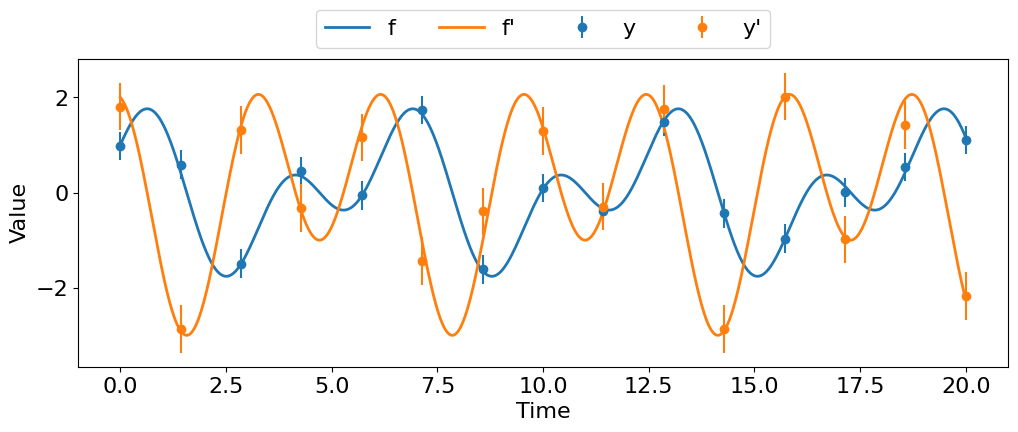

In [5]:
def f(t):
    return jnp.sin(2 * t) + jnp.cos(t)

def fp(t):
    return -jnp.sin(t) + 2 * jnp.cos(2 * t)

# Simulate some data
yerr_train = jax.random.multivariate_normal(key, mean=jnp.zeros(2), cov=R, shape=(len(t),))
y_train = jnp.stack([f(t), fp(t)], axis=-1) + yerr_train

# Plot the data and the true function
ts = jnp.linspace(0, 20, 1000)
fig, ax = plt.subplots(1,1, figsize=(12,4))
ax.plot(ts, f(ts), '-',  color='C0', lw=2, label='f')
ax.plot(ts, fp(ts), '-', color='C1', lw=2, label='f\'')
ax.errorbar(t, y_train[:, 0], yerr=sigma_y,  color='C0', fmt='o', label='y')
ax.errorbar(t, y_train[:, 1], yerr=sigma_yp, color='C1', fmt='o', label='y\'')
ax.set(xlabel='Time', ylabel='Value')
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1));

Now, let's condition the GP on the data

In [6]:
llh, condGP = gp.condition(y_train)

and plot the prediction

In [7]:
ypred, yvarpred = condGP.predict(ts, return_var=True)
yerrpred = jnp.sqrt(jnp.array([yvarpred[:, 0, 0], yvarpred[:, 1, 1]]))

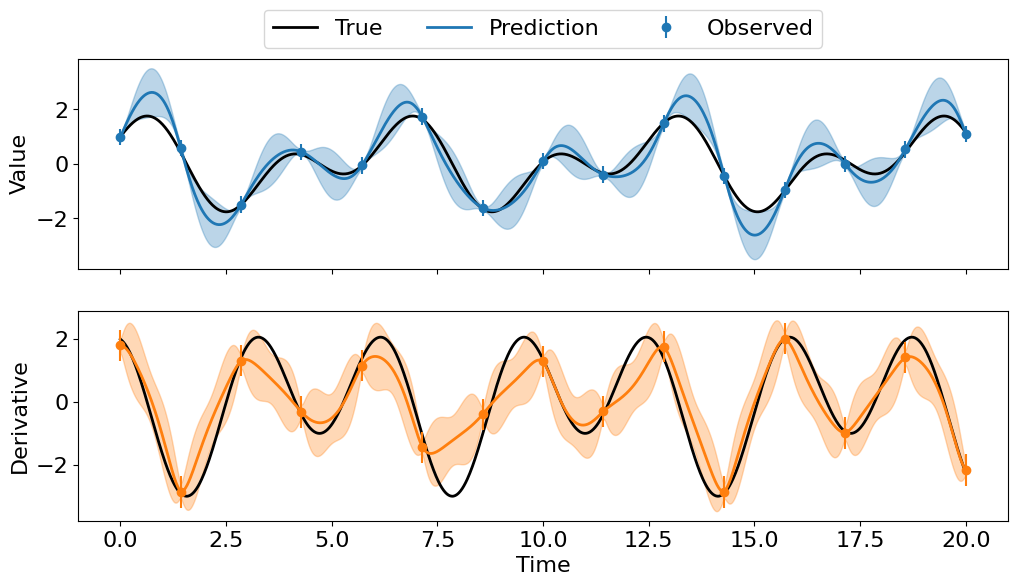

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
axes[0].plot(ts, f(ts), '-',  color='k', lw=2, label='True')
axes[0].errorbar(t, y_train[:, 0], yerr=sigma_y,  color='C0', fmt='o', label='Observed')
axes[0].plot(ts, ypred[:, 0], '-', color='C0', lw=2, label='Prediction')
axes[0].fill_between(ts, ypred[:, 0] - yerrpred[0], ypred[:, 0] + yerrpred[0], color='C0', alpha=0.3)

axes[1].plot(ts, fp(ts), '-', color='k', lw=2, label='True')
axes[1].errorbar(t, y_train[:, 1], yerr=sigma_yp, color='C1', fmt='o', label='Observed')
axes[1].plot(ts, ypred[:, 1], '-', color='C1', lw=2, label='Prediction')
axes[1].fill_between(ts, ypred[:, 1] - yerrpred[1], ypred[:, 1] + yerrpred[1], color='C1', alpha=0.3)  
axes[0].set(ylabel='Value')
axes[1].set(xlabel='Time', ylabel='Derivative')
axes[0].legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1));